# Fitting observed w_p(R) with Dark Emulator

This notebook shows how to fit **galaxy clustering** observational data (projected correlation function w_p(R)) using Dark Emulator and cloelike.

Workflow:
1. Prepare observational data (or mock data)
2. Set up the GC likelihood with `EuclidLikelihood_DarkEmu_RealSpace`
3. Optimize (or run MCMC) to fit cosmology and HOD parameters

## 1. Path and imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

NOTEBOOK_DIR = Path.cwd()
CLOE_ROOT = NOTEBOOK_DIR.parent.parent.parent  # tutorials/dark_emulator -> CLOE
sys.path.insert(0, str(CLOE_ROOT / "cloelib"))
sys.path.insert(0, str(CLOE_ROOT / "cloelike"))
sys.path.insert(0, str(CLOE_ROOT / "dark_emulator_public"))

from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.darkemu_cosmology import DarkEmuHODPerturbations
from cloelib.observables.darkemu_hod import DarkEmuHODParameters
from cloelike.EuclidLikelihood_DarkEmu_RealSpace import EuclidLikelihood_DarkEmu_RealSpace

print("CLOE_ROOT:", CLOE_ROOT)

CLOE_ROOT: /home/ryuseikano/Euclid/CLOE


## 2. Observational data

In this notebook we **generate mock data** in the format below for demonstration (fiducial cosmology + HOD + noise). You can replace the next cell with loading your own observed w_p(R) and covariance.

**Data format (expected by the likelihood):**
- `wp`: observed w_p [h⁻¹ Mpc]
- `R_bins`: projected radii [h⁻¹ Mpc]
- `z_sample`: sample redshift
- `pimax`: line-of-sight integration limit [h⁻¹ Mpc]
- `covariance`: covariance matrix

In [2]:
# Fiducial parameters (for mock data)
FIDUCIAL_COSMO = {
    "H0": 67.0,
    "Omega_cdm0": 0.27,
    "Omega_b0": 0.049,
    "Omega_k0": 0.0,
    "w0": -1.0,
    "wa": 0.0,
    "ns": 0.96,
    "As": 2.1e-9,
    "gamma_MG": 0.55,
    "mnu": 0.06,
    "N_mnu": 1,
}
FIDUCIAL_HOD = {
    "logMmin": 13.0,
    "sigma_sq": 0.3,
    "logM1": 14.0,
    "alpha": 1.0,
    "kappa": 1.0,
    "poff": 0.0,
    "Roff": 0.0,
}

# --- Mock observational data (replace with real data loading) ---
z_sample = 0.5
pimax = 100.0
R_bins = np.logspace(-0.5, 1.5, 15)

background = CAMBBackground(**FIDUCIAL_COSMO)
hod_params = DarkEmuHODParameters(**FIDUCIAL_HOD)
pert = DarkEmuHODPerturbations(
    background=background,
    redshifts=np.array([z_sample]),
    hod_params=hod_params,
)
wp_fid = pert.projected_correlation(R_bins, z_sample, pimax=pimax)

np.random.seed(42)
noise_level = 0.1
sigma_wp = noise_level * np.abs(wp_fid)
cov_wp = np.diag(sigma_wp ** 2)
wp_obs = wp_fid + np.random.randn(len(R_bins)) * sigma_wp

data_gc = {
    "wp": wp_obs,
    "R_bins": R_bins,
    "z_sample": z_sample,
    "pimax": pimax,
    "covariance": cov_wp,
}
print("Mock GC data:", len(R_bins), " bins, z_sample =", z_sample)

/home/ryuseikano/Euclid/CLOE/cloelib/cloelib/cosmology/darkemu_cosmology.py:131: UserWarning: Neutrino density mismatch: input omega_nu = 0.000000, but Dark Emulator assumes fixed omega_nu = 0.00064. Dark Emulator will use its internal fixed value regardless of input.
  self.cparam = background_to_darkemu_cparam(background)


Mock GC data: 15  bins, z_sample = 0.5


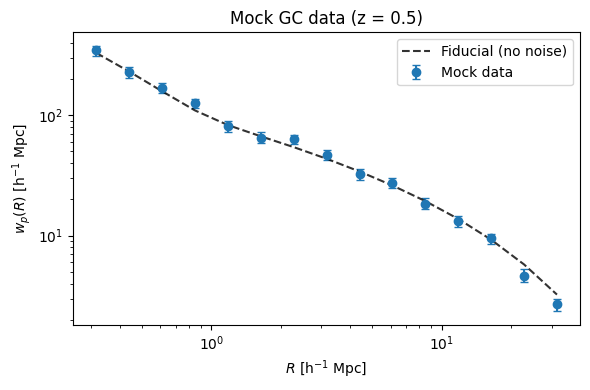

In [3]:
# Plot mock data: w_p(R) with error bars; fiducial curve for reference
plt.figure(figsize=(6, 4))
plt.errorbar(R_bins, wp_obs, yerr=sigma_wp, fmt="o", capsize=3, label="Mock data")
plt.plot(R_bins, wp_fid, "k--", alpha=0.8, label="Fiducial (no noise)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$R$ [h$^{-1}$ Mpc]")
plt.ylabel(r"$w_p(R)$ [h$^{-1}$ Mpc]")
plt.legend()
plt.title("Mock GC data (z = {})".format(z_sample))
plt.tight_layout()
plt.show()

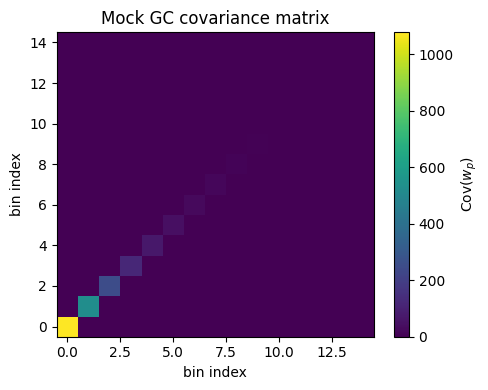

In [4]:
# Covariance matrix (diagonal for this mock)
plt.figure(figsize=(5, 4))
plt.imshow(cov_wp, aspect="auto", cmap="viridis", origin="lower")
plt.colorbar(label=r"$\mathrm{Cov}(w_p)$")
plt.xlabel("bin index")
plt.ylabel("bin index")
plt.title("Mock GC covariance matrix")
plt.tight_layout()
plt.show()

## 3. Likelihood and scale cuts

Set up the GC likelihood with `EuclidLikelihood_DarkEmu_RealSpace` (data_gc only).

In [5]:
settings = {
    # if you want to apply scale cuts
    # "R_min_gc": 2.0,
    # "R_max_gc": 30.0,
    "hod_params_fixed": {
        "kappa": FIDUCIAL_HOD["kappa"],
        "poff": FIDUCIAL_HOD["poff"],
        "Roff": FIDUCIAL_HOD["Roff"],
    },
}

likelihood = EuclidLikelihood_DarkEmu_RealSpace(
    data_gc=data_gc,
    settings=settings,
    Background=CAMBBackground,
)
print("Data points after scale cuts:", likelihood.n_gc)

Data points after scale cuts: 15


In [6]:
def full_params_from_vector(x):
    """Map free parameters to full parameter dict."""
    return {
        **FIDUCIAL_COSMO,
        "logMmin": x[0],
        "sigma_sq": x[1],
        "logM1": x[2],
        "alpha": x[3],
        **settings["hod_params_fixed"],
    }

def neg_loglike_gc(x):
    """−log L for free params x = [logMmin, sigma_sq, logM1, alpha]."""
    return -likelihood.loglike(full_params_from_vector(x))

## 4. Fitting

Minimize −log L over HOD parameters (cosmology fixed here).

In [7]:
x0 = [FIDUCIAL_HOD["logMmin"], FIDUCIAL_HOD["sigma_sq"], FIDUCIAL_HOD["logM1"], FIDUCIAL_HOD["alpha"]]
bounds = [(12.0, 14.0), (0.05, 0.6), (13.0, 15.0), (0.5, 1.5)]

result = minimize(neg_loglike_gc, x0, method="L-BFGS-B", bounds=bounds)
best = result.x
print("Best-fit HOD: logMmin = {:.3f}, sigma_sq = {:.3f}, logM1 = {:.3f}, alpha = {:.3f}".format(*best))
print("−log L at best fit:", result.fun)

Best-fit HOD: logMmin = 12.678, sigma_sq = 0.050, logM1 = 13.778, alpha = 1.193
−log L at best fit: 5.877255168420394


## 5. Plot: data vs best-fit theory

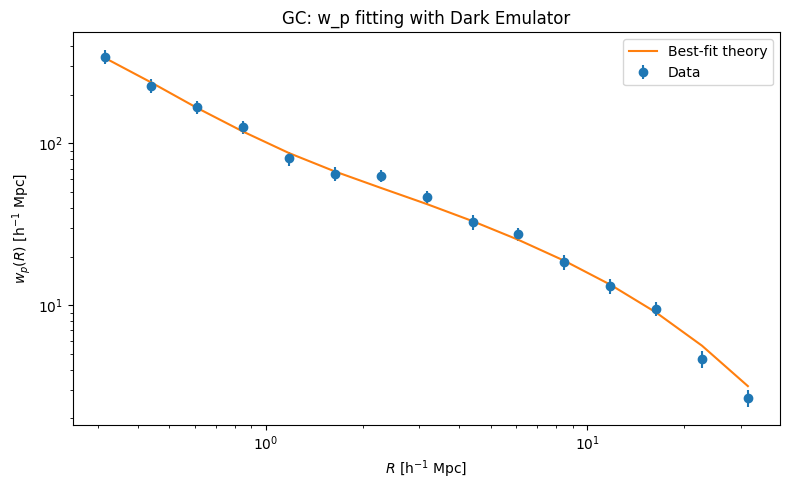

In [9]:
params_best = full_params_from_vector(best)
theory_full = likelihood.get_theory_vector(params_best)
theory_gc = theory_full[: likelihood.n_gc]
R_plot = likelihood.R_bins_gc
data_plot = likelihood.data_vector[: likelihood.n_gc]

# Use scale cuts if provided, otherwise use all R_bins (default: 0.0 to np.inf)
R_min = settings.get("R_min_gc", 0.0)
R_max = settings.get("R_max_gc", np.inf)
mask = (data_gc["R_bins"] >= R_min) & (data_gc["R_bins"] <= R_max)
cov_cut = np.asarray(data_gc["covariance"])[np.outer(mask, mask)].reshape(mask.sum(), mask.sum())
sigma_plot = np.sqrt(np.diag(cov_cut))

plt.figure(figsize=(8, 5))
plt.errorbar(R_plot, data_plot, yerr=sigma_plot, fmt="o", label="Data")
plt.loglog(R_plot, theory_gc, "-", label="Best-fit theory")
plt.xlabel(r"$R$ [h$^{-1}$ Mpc]")
plt.ylabel(r"$w_p(R)$ [h$^{-1}$ Mpc]")
plt.legend()
plt.title("GC: w_p fitting with Dark Emulator")
plt.tight_layout()
plt.show()